# Task 1. Sentiment Analysis

### I. Machine Learning Approach

#### **1. Load data and Exploratory Data Analysis (EDA)**

In [5]:
import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/banhmuy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/banhmuy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/banhmuy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
DATASET_PATH = '../data/train.txt'

df = pd.read_csv(
    DATASET_PATH,
    sep=',',
    header=0,
    names=['id', 'class', 'text'],
    skiprows=1,
    dtype={'id': str, 'class': str, 'text': str}
)

In [7]:
df.head(5)

,id,class,text
0,1,Neg,The last business trip I drove to San Franci...
1,2,Neg,My husband and I purchased a 1990 Ford F250 a...
2,3,Neg,I feel I have a thorough opinion of this truc...
3,4,Neg,AS a mother of 3 all of whom are still in ca...
4,5,Neg,The Ford Winstar is a car that I would not re...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1223 entries, 0 to 1222
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1223 non-null   object
 1   class   1223 non-null   object
 2   text    1223 non-null   object
dtypes: object(3)
memory usage: 28.8+ KB


In [9]:
# Check for nun values
df.isnull().sum()

id       0
class    0
text     0
dtype: int64

Text(0.5, 1.0, 'Distribution of Car Review Classes')

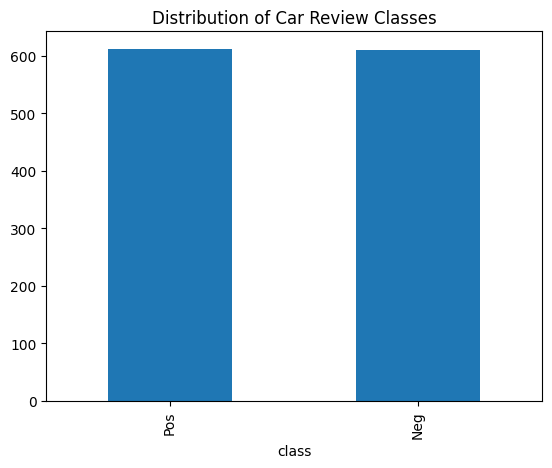

In [10]:
# Distribution of classes
df['class'].value_counts().plot(kind='bar')
plt.title('Distribution of Car Review Classes')
# Data has only positive and negative reviews

In [11]:
# Summary statistics of text lengths
df['text'].str.len().describe()

count     1223.000000
mean      2357.362224
std       2371.214585
min        495.000000
25%       1078.500000
50%       1600.000000
75%       2646.500000
max      21198.000000
Name: text, dtype: float64

#### **2. Text Preprocessing**

Data is clean, the dataset now contain 1223 rows with 3 columns

In [2]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("Model downloaded successful!")

Model downloaded successful!


In [3]:
import string
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# It's good practice to ensure the necessary NLTK data is downloaded
# nltk.download('punkt')
# nltk.download('stopwords')


# Download English model for spaCy if not already downloaded
nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    """
    Applies lemmatization to a list of tokens using spaCy.
    Input: list of str (tokens)
    Output: list of str (lemmatized tokens)
    """
    # Combine them into a sentence so that spaCy can process the context and POS tag.
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

def punctuation_removal(text):
    """Removes punctuation from text."""
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

def remove_stopwords(tokens):
    """Removes English stopwords from a list of tokens."""
    stop_words = set(stopwords.words('english'))
    # The list comprehension is the most efficient way to do this.
    return [token for token in tokens if token not in stop_words]

def stemming(tokens): # can be improved with Lemmatization
    """Applies Porter Stemmer to a list of tokens."""
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]

def preprocess_text(text):
    """
    Applies a full preprocessing pipeline to a list of text documents.
    """

    # 1. Lowercase the text
    text = text.lower()

    # 2. Remove punctuation
    # The text data we are using does not contain punctuation.
    text = punctuation_removal(text)

    # 3. Tokenize the cleaned text
    tokens = word_tokenize(text)

    # 4. Remove stopwords
    tokens = remove_stopwords(tokens)

    # 5. Apply lemmatization
    # tokens = stemming(tokens)
    tokens = lemmatize(tokens)

    tokens = ' '.join(tokens)

    return tokens

# --- Example Usage ---
sample_texts = [
    "This is the first document; it is amazing!",
    "Here is the second one, which is also interesting."
]

processed_data = preprocess_text(sample_texts[0])
print(processed_data)
# Stem Output: [['first', 'document', 'amaz'], ['second', 'one', 'also', 'interest']]

first document amazing


In [12]:
df['clean_text'] = df['text'].apply(preprocess_text)
df.head()

,id,class,text,clean_text
0,1,Neg,The last business trip I drove to San Franci...,last business trip drive san francisco go hert...
1,2,Neg,My husband and I purchased a 1990 Ford F250 a...,husband purchase 1990 ford f250 nothing proble...
2,3,Neg,I feel I have a thorough opinion of this truc...,feel thorough opinion truck compare post evalu...
3,4,Neg,AS a mother of 3 all of whom are still in ca...,mother 3 still carseat logical thing trade 200...
4,5,Neg,The Ford Winstar is a car that I would not re...,ford winstar car would recommend purchasing dr...


#### **3. Train/Test Split**

In [29]:
TEST_SIZE = 0.2
SEED = 42

X = df['clean_text']
y = df['class'].map({'Pos': 1, 'Neg': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    random_state=SEED)

print(f'Number of training samples: {X_train.shape[0]}')
print(f'Number of test samples: {X_test.shape[0]}')

Number of training samples: 978
Number of test samples: 245


In [30]:
print(f"X_train first 5 samples:\n {X_train.head()}")

X_train first 5 samples:
 584    point point talk ford focus lx sedan buy ford ...
966    ok review 97gt 89gt mustang currently locate w...
10     suv sob pm great deadly combination old mad wo...
514    three year ago finally could offer brand new c...
424    use drive 88 full size bronco eddie bauer take...
Name: clean_text, dtype: object


#### **4. Feature Engineering**

Using TF-IDF with n-gram

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
stop_words = set(stopwords.words('english'))
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # capture bigrams like "not good"
    stop_words='english'
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#### **5. Train model**

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

#### **6. Evaluation**

In [37]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79       129
           1       0.74      0.88      0.80       116

    accuracy                           0.80       245
   macro avg       0.80      0.80      0.80       245
weighted avg       0.81      0.80      0.80       245



#### **7. Compare to model**

### II.  LLM-based approach

# Task 2. Topic Extraction

### I. Machine Learning Approach

### II.  LLM-based approach